# Voyage Analytics — Exploratory Data Analysis

Dataset: a Brazilian travel platform's `users`, `flights`, and `hotels` tables.
This notebook explores the raw data before any feature engineering or modeling,
to understand distributions, relationships, and data quality.

In [1]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_prep import load_raw, build_user_features

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

users, flights, hotels = load_raw()
print('Users:', users.shape)
print('Flights:', flights.shape)
print('Hotels:', hotels.shape)

Users: (1340, 5)
Flights: (271888, 10)
Hotels: (40552, 8)


## 1. Data quality check

In [2]:
print('Missing values:')
print('users:\n', users.isnull().sum())
print('flights:\n', flights.isnull().sum())
print('hotels:\n', hotels.isnull().sum())
print()
print('Duplicate rows:', users.duplicated().sum(), flights.duplicated().sum(), hotels.duplicated().sum())

Missing values:
users:
 code       0
company    0
name       0
gender     0
age        0
dtype: int64
flights:
 travelCode    0
userCode      0
from          0
to            0
flightType    0
price         0
time          0
distance      0
agency        0
date          0
dtype: int64
hotels:
 travelCode    0
userCode      0
name          0
place         0
days          0
price         0
total         0
date          0
dtype: int64

Duplicate rows: 0 0 0


No missing values and no duplicate rows in any of the three tables — the data is clean going in.

## 2. Users overview

In [3]:
users.head()

,code,company,name,gender,age
0,0,4You,Roy Braun,male,21
1,1,4You,Joseph Holsten,male,37
2,2,4You,Wilma Mcinnis,female,48
3,3,4You,Paula Daniel,female,23
4,4,4You,Patricia Carson,female,44


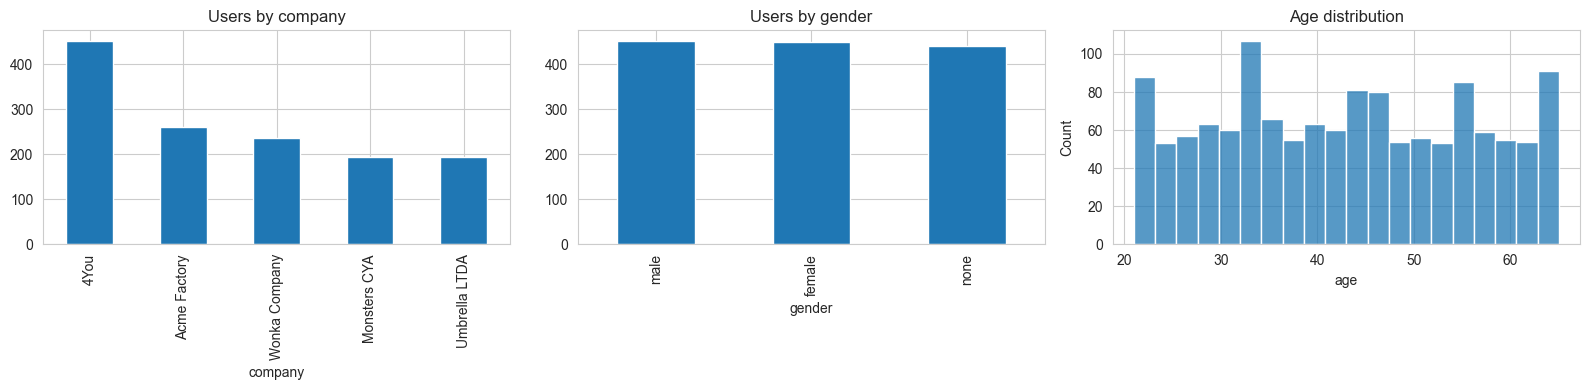

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
users['company'].value_counts().plot(kind='bar', ax=axes[0], title='Users by company')
users['gender'].value_counts().plot(kind='bar', ax=axes[1], title='Users by gender')
sns.histplot(users['age'], bins=20, ax=axes[2])
axes[2].set_title('Age distribution')
plt.tight_layout()
plt.show()

In [5]:
print(users['age'].describe())

count    1340.000000
mean       42.742537
std        12.869779
min        21.000000
25%        32.000000
50%        42.000000
75%        54.000000
max        65.000000
Name: age, dtype: float64


## 3. Flights overview

In [6]:
flights.head()

,travelCode,userCode,from,to,flightType,price,time,distance,agency,date
0,0,0,Recife (PE),Florianopolis (SC),firstClass,1434.38,1.76,676.53,FlyingDrops,2019-09-26
1,0,0,Florianopolis (SC),Recife (PE),firstClass,1292.29,1.76,676.53,FlyingDrops,2019-09-30
2,1,0,Brasilia (DF),Florianopolis (SC),firstClass,1487.52,1.66,637.56,CloudFy,2019-10-03
3,1,0,Florianopolis (SC),Brasilia (DF),firstClass,1127.36,1.66,637.56,CloudFy,2019-10-04
4,2,0,Aracaju (SE),Salvador (BH),firstClass,1684.05,2.16,830.86,CloudFy,2019-10-10


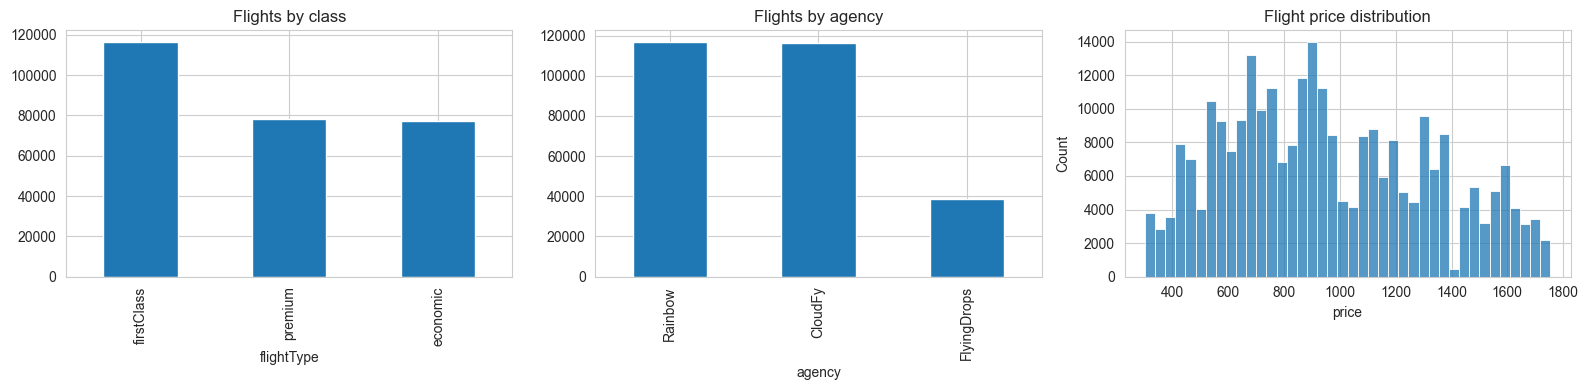

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
flights['flightType'].value_counts().plot(kind='bar', ax=axes[0], title='Flights by class')
flights['agency'].value_counts().plot(kind='bar', ax=axes[1], title='Flights by agency')
sns.histplot(flights['price'], bins=40, ax=axes[2])
axes[2].set_title('Flight price distribution')
plt.tight_layout()
plt.show()

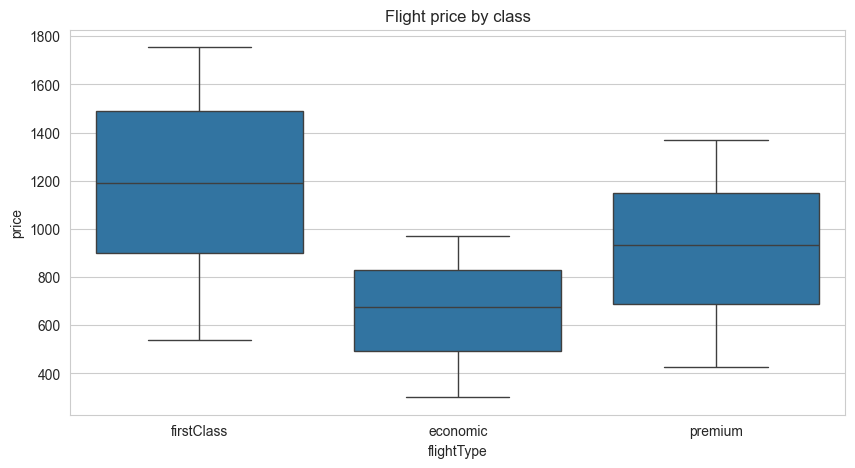

               count         mean         std     min      25%      50%  \
flightType                                                                
economic     77466.0   658.443093  192.901686  301.51  494.290   674.52   
firstClass  116418.0  1181.067727  346.419970  539.39  898.040  1190.94   
premium      78004.0   920.392375  276.945775  427.25  690.205   932.84   

                75%      max  
flightType                    
economic     829.91   972.12  
firstClass  1487.52  1754.17  
premium     1149.53  1370.17  


In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=flights, x='flightType', y='price')
plt.title('Flight price by class')
plt.show()

print(flights.groupby('flightType')['price'].describe())

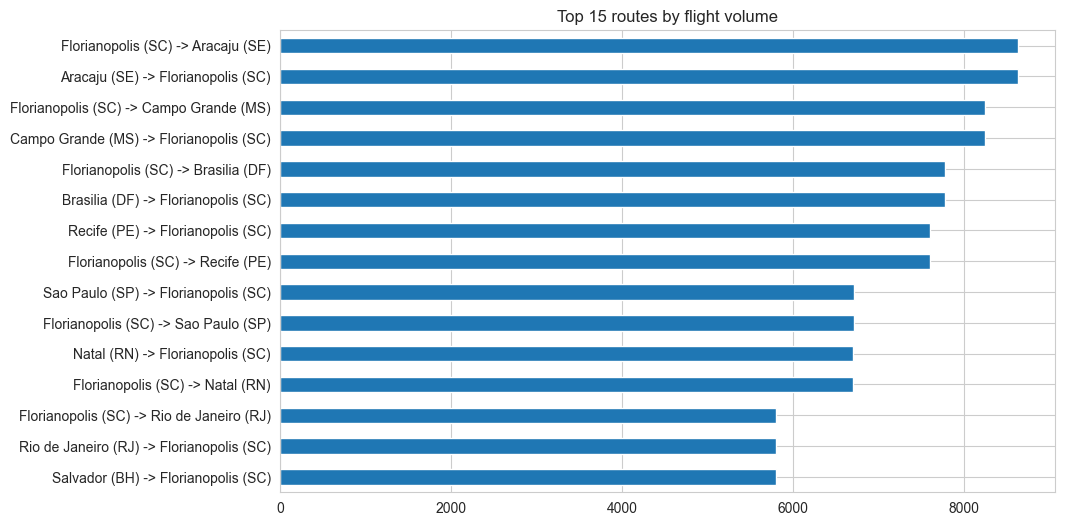

In [9]:
route_counts = (flights['from'] + ' -> ' + flights['to']).value_counts().head(15)
plt.figure(figsize=(10, 6))
route_counts.plot(kind='barh')
plt.title('Top 15 routes by flight volume')
plt.gca().invert_yaxis()
plt.show()

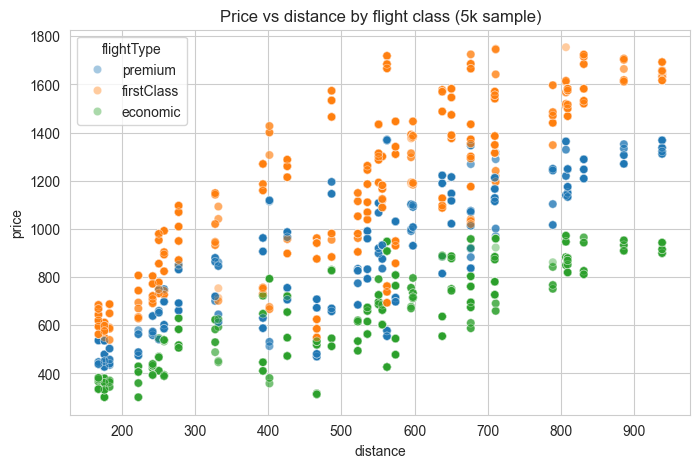

Correlation between distance and price: 0.642


In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=flights.sample(5000, random_state=42), x='distance', y='price', hue='flightType', alpha=0.4)
plt.title('Price vs distance by flight class (5k sample)')
plt.show()

print('Correlation between distance and price:', flights['distance'].corr(flights['price']).round(3))

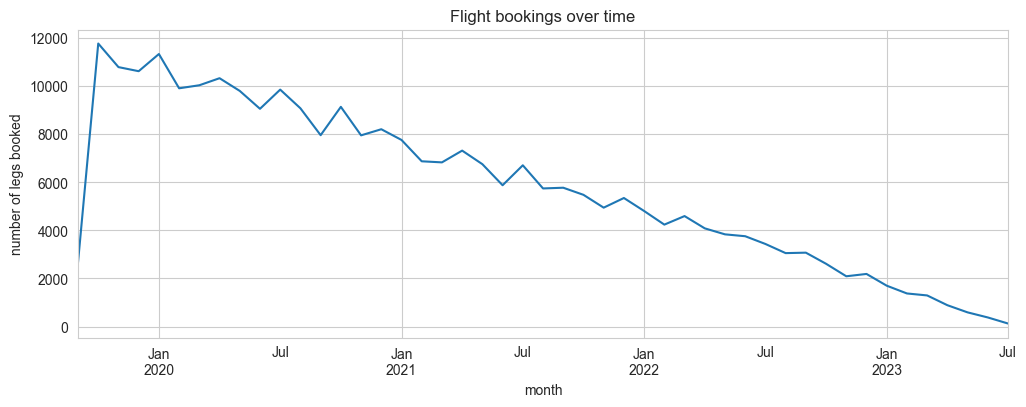

In [11]:
flights['month'] = pd.to_datetime(flights['date']).dt.to_period('M')
monthly = flights.groupby('month').size()
plt.figure(figsize=(12, 4))
monthly.plot()
plt.title('Flight bookings over time')
plt.ylabel('number of legs booked')
plt.show()

## 4. Hotels overview

In [12]:
hotels.head()

,travelCode,userCode,name,place,days,price,total,date
0,0,0,Hotel A,Florianopolis (SC),4,313.02,1252.08,2019-09-26
1,2,0,Hotel K,Salvador (BH),2,263.41,526.82,2019-10-10
2,7,0,Hotel K,Salvador (BH),3,263.41,790.23,2019-11-14
3,11,0,Hotel K,Salvador (BH),4,263.41,1053.64,2019-12-12
4,13,0,Hotel A,Florianopolis (SC),1,313.02,313.02,2019-12-26


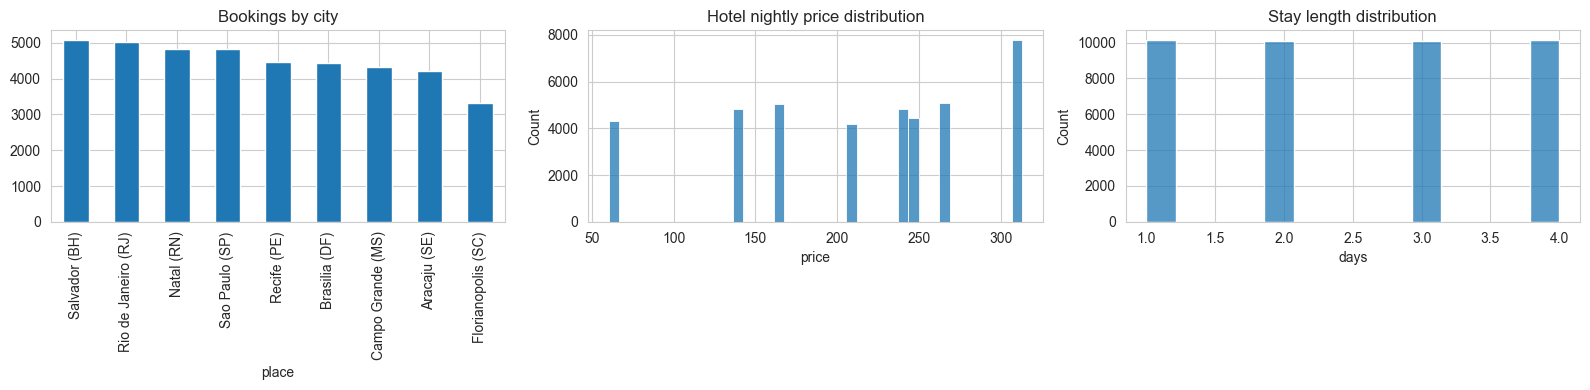

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
hotels['place'].value_counts().plot(kind='bar', ax=axes[0], title='Bookings by city')
sns.histplot(hotels['price'], bins=40, ax=axes[1])
axes[1].set_title('Hotel nightly price distribution')
sns.histplot(hotels['days'], bins=14, ax=axes[2])
axes[2].set_title('Stay length distribution')
plt.tight_layout()
plt.show()

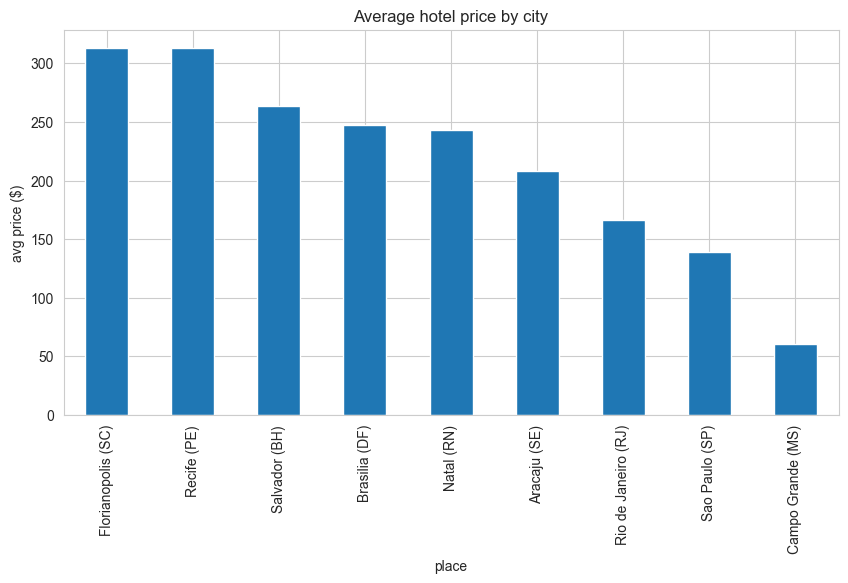

In [14]:
avg_price_by_place = hotels.groupby('place')['price'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
avg_price_by_place.plot(kind='bar')
plt.title('Average hotel price by city')
plt.ylabel('avg price ($)')
plt.show()

## 5. User-level behaviour (merged view)

Aggregating flights + hotels per user gives the feature table used by the segmentation and churn models downstream.

In [15]:
user_features = build_user_features(users, flights, hotels)
user_features.describe()[['n_trips', 'total_spend', 'avg_stay_days', 'days_active']]

,n_trips,total_spend,avg_stay_days,days_active
count,1340.000000,1340.000000,1310.000000,1340.000000
mean,101.450746,210480.568172,2.504979,705.664925
min,0.000000,0.000000,1.000000,0.000000
25%,50.000000,103829.307500,2.333333,344.000000
50%,99.500000,202335.955000,2.500000,692.500000
75%,155.000000,320162.315000,2.647059,1079.250000
max,200.000000,476952.820000,4.000000,1397.000000
std,59.096760,124516.659362,0.314866,413.682651


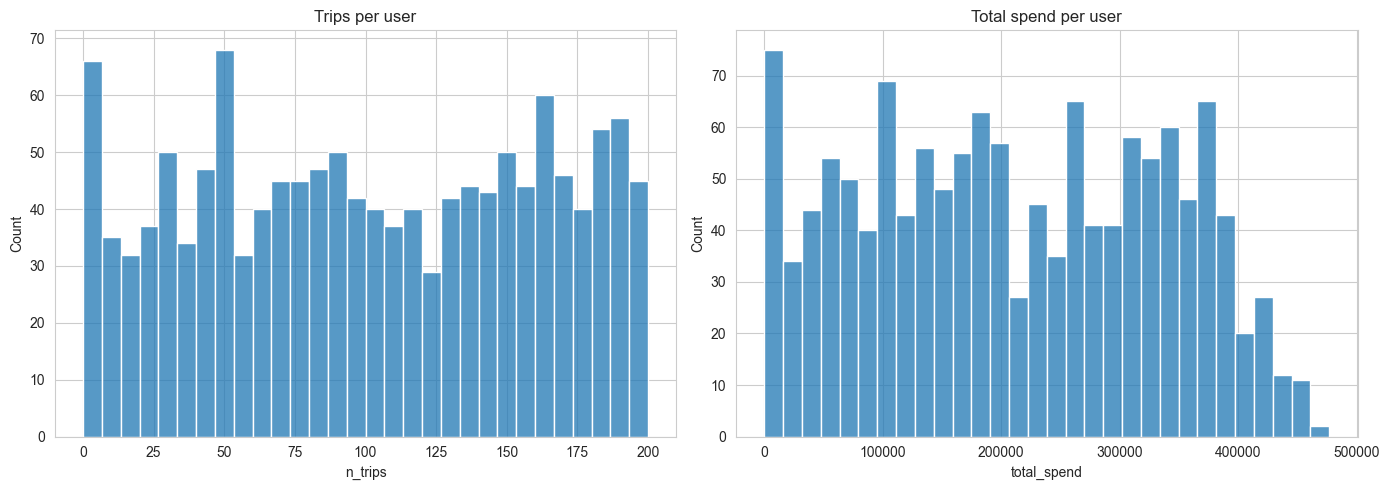

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(user_features['n_trips'], bins=30, ax=axes[0])
axes[0].set_title('Trips per user')
sns.histplot(user_features['total_spend'], bins=30, ax=axes[1])
axes[1].set_title('Total spend per user')
plt.tight_layout()
plt.show()

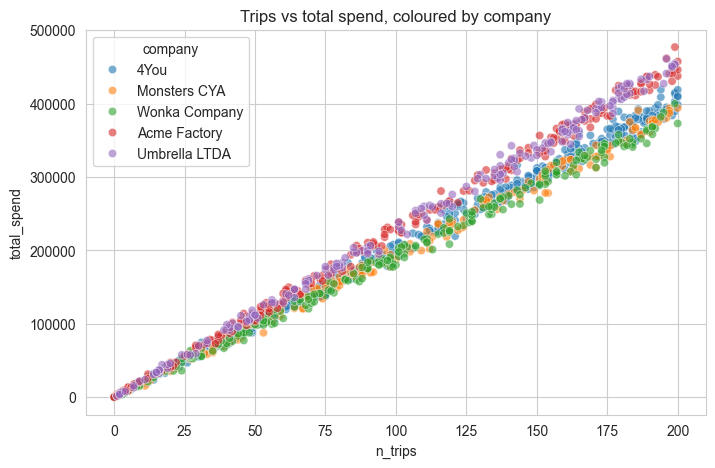

In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=user_features, x='n_trips', y='total_spend', hue='company', alpha=0.6)
plt.title('Trips vs total spend, coloured by company')
plt.show()

## 6. Key takeaways

- The data is clean: no missing values, no duplicates, across all three tables.
- Flight price scales with distance but flight **class** (economic / premium / firstClass) is the dominant driver of price spread — this shapes the feature set for the price prediction model.
- Only 9 cities exist in the network, so many frequent travellers end up visiting all of them — this matters for the recommender, which needs a fallback for "visited everywhere" users.
- User-level spend and trip counts are right-skewed with a long tail of high-value travellers, which is exactly the kind of structure KMeans segmentation can separate out.
- Bookings are fairly steady over time with some monthly variation, useful context for the price models' seasonal features.

Next: `02_price_prediction.ipynb`, `03_customer_segmentation.ipynb`, `04_churn_prediction.ipynb`, `05_recommendation_system.ipynb`.